## **Part 4. Query data from the PowerCo database**

Having established a centralised database, now everyone at PowerCo can access the database if they are provided with the password. 
In Part 3, you have connected to the PostgreSQL database from DBeaver. Below you will learn how to connect directly from Python.

In [2]:
import psycopg # this library is used to connect to the postgreSQL server and its databases
import pandas as pd

conn = psycopg.connect(
    host="localhost", # this is the default value that you have chosen in the installation
    port=5432, # this is the default value that you have chosen in the installation
    dbname= "powerco", # insert your database name here   
    user="postgres", # this is the default username 
    password="studygroup11"
)

OperationalError: connection failed: connection to server at "127.0.0.1", port 5432 failed: FATAL:  database "powerco" does not exist
Multiple connection attempts failed. All failures were:
- host: 'localhost', port: 5432, hostaddr: '::1': connection failed: connection to server at "::1", port 5432 failed: FATAL:  database "powerco" does not exist
- host: 'localhost', port: 5432, hostaddr: '127.0.0.1': connection failed: connection to server at "127.0.0.1", port 5432 failed: FATAL:  database "powerco" does not exist

Now, you can use the connection exactly as you have done for Session 1 and 2. The goal of Part 4 is to create a single SQL query that gets all the data we need for the analysis from all the tables in the database.

We will proceed step by step. In the following, write SQL queries and execute them with Pandas as you have done in Session 1 & 2.

**Step 1: Write a query to get settlement_date, period and england_wales_demand from the energy_demand table**

In [7]:
# Add python code here to get the data from the db and save it in a pandas dataframe
# You can also try out the query in DBeaver: check Session1 to see how to do that if you don't remember
query1 = """  
SELECT settlement_date, settlement_period, england_wales_demand
FROM public.energy_demand
"""

energy_1 = pd.read_sql(query1, conn)
energy_df1 = pd.DataFrame(energy_1)
energy_df1.head()

/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/3332044374.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  energy_1 = pd.read_sql(query1, conn)


,settlement_date,settlement_period,england_wales_demand
0,2015-01-01,1,26351
1,2015-01-01,2,27001
2,2015-01-01,3,26874
3,2015-01-01,4,25824
4,2015-01-01,5,24752


In [8]:
query_energy = """
SELECT *
FROM public.energy_demand
"""

energy_general = pd.read_sql(query_energy, conn)
energy_df_general = pd.DataFrame(energy_general)
energy_df_general.head(5)

/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/3867284094.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  energy_general = pd.read_sql(query_energy, conn)


,surrogate_key,column1,settlement_date,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,...,ifa2_flow,britned_flow,moyle_flow,east_west_flow,nemo_flow,nsl_flow,eleclink_flow,viking_flow,greenlink_flow,scottish_transfer
0,1,0,2015-01-01,1,28726,29490,26351,2211,4039,0,...,0,854,-25,-121,0,,,,,
1,2,1,2015-01-01,2,29391,30135,27001,2177,4039,0,...,0,903,3,-121,0,,,,,
2,3,2,2015-01-01,3,29231,30448,26874,2224,4039,0,...,0,888,-53,-121,0,,,,,
3,4,3,2015-01-01,4,28095,29381,25824,2270,4039,0,...,0,864,-40,-56,0,,,,,
4,5,4,2015-01-01,5,26896,28667,24752,2246,4039,0,...,0,881,-82,-7,0,,,,,


**Step 2: Write a query to aggregate the demand on a daily basis.**

If you remember, there are multiple settlement_period in a given settlement_date: we want to aggregate the data at a daily level, that is by settlement_date. 

Metrics that you might want to consider are the total sum of daily demand (call it daily_demand), its daily average (call it daily_avg_demand) and its daily peak (call it daily_peak_demand).

Remember to order the resulting dataframe, so that the time ordering is respected! 

In [9]:
# select columns from energy db and aggregate by day to get daily total, average and peak demand
query2 = """  
SELECT settlement_date, SUM(england_wales_demand) AS daily_demand, AVG(england_wales_demand) AS daily_avg_demand, MAX(england_wales_demand) AS daily_peak_demand
FROM public.energy_demand
GROUP BY settlement_date 
"""

daily_agg_demand = pd.read_sql(query2, conn)
daily_demand_df = pd.DataFrame(daily_agg_demand)
daily_demand_df.head()



/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/649466028.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  daily_agg_demand = pd.read_sql(query2, conn)


,settlement_date,daily_demand,daily_avg_demand,daily_peak_demand
0,2016-09-27,1316131,27419.395833,35428
1,2019-02-07,1522121,31710.854167,40338
2,2015-10-10,1280275,26672.395833,34250
3,2015-12-31,1308072,27251.500000,36551
4,2015-09-08,1384257,28838.687500,35026


**Step 3: write a query that joins the daily demand data with the calendar table**

For the time being, keep only the is_bank_holiday variable (which has "null" values at the moment).

I have started writing the query for you. The first bit allows you to use the result from query2 as a temporary table called demand_daily_table. 

Continue the JOIN statement as if "demand_daily_table" was an actual table from the database!


In [10]:
# join daily demand table with calendar table 
query3 = """
    WITH demand_daily_table AS (
    SELECT settlement_date, SUM(england_wales_demand) AS daily_demand, AVG(england_wales_demand) AS daily_avg_demand, MAX(england_wales_demand) AS daily_peak_demand
FROM public.energy_demand
GROUP BY settlement_date 
    )

    SELECT calendar.is_bank_holiday, demand_daily_table.*
    FROM calendar
    JOIN demand_daily_table ON demand_daily_table.settlement_date = calendar.date
"""

bank_holiday_info = pd.read_sql(query3, conn)
bank_holiday_df = pd.DataFrame(bank_holiday_info)
bank_holiday_df.head()

/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/1529107130.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  bank_holiday_info = pd.read_sql(query3, conn)


,is_bank_holiday,settlement_date,daily_demand,daily_avg_demand,daily_peak_demand
0,None,2015-01-01,1327622,27658.791667,35626
1,None,2015-01-02,1440094,30001.958333,41296
2,None,2015-01-03,1506044,31375.916667,40980
3,None,2015-01-04,1534289,31964.354167,42170
4,None,2015-01-05,1722391,35883.145833,45139


In [11]:
# look at variables in weather observation table
# query_obs = """
# SELECT *
# FROM public.weather_observation
# """
# weath_obs = pd.read_sql(query_obs, conn)
# weath_obs_df = pd.DataFrame(weath_obs)
# weath_obs_df.head()

**Step 4: Expand the previous query so that it will also join the information from the weather_observation table too.**

Save the result of the query in a dataframe called df_weather_obs! 

In [12]:
# join daily demand table with calendar table and weather observation table
query4 = """
    WITH demand_daily_table AS (
    SELECT settlement_date, SUM(england_wales_demand) AS daily_demand, AVG(england_wales_demand) AS daily_avg_demand, MAX(england_wales_demand) AS daily_peak_demand
FROM public.energy_demand
GROUP BY settlement_date 
    )

    SELECT calendar.is_bank_holiday, demand_daily_table.*, weather_observation.*
    FROM calendar
    JOIN demand_daily_table ON demand_daily_table.settlement_date = calendar.date
    JOIN weather_observation ON weather_observation.time = calendar.date
"""
weather_obs = pd.read_sql(query4, conn)
df_weather_obs = pd.DataFrame(weather_obs)
df_weather_obs = df_weather_obs.drop(columns=['column1'])
# df_weather_obs.head()

/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/750461733.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  weather_obs = pd.read_sql(query4, conn)


**Step 5: Repeat the same query from step 4 using the information from weather_forecast rather than weather_observation**

Save the result in a DataFrame called df_weather_forecast!

In [13]:
# join daily demand table with calendar table and weather forecast table
query5 = """
    WITH demand_daily_table AS (
    SELECT settlement_date, SUM(england_wales_demand) AS daily_demand, AVG(england_wales_demand) AS daily_avg_demand, MAX(england_wales_demand) AS daily_peak_demand
FROM public.energy_demand
GROUP BY settlement_date
    )

    SELECT calendar.is_bank_holiday, demand_daily_table.*, weather_forecast.*
    FROM calendar
    JOIN demand_daily_table ON demand_daily_table.settlement_date = calendar.date
    JOIN weather_forecast ON demand_daily_table.settlement_date = weather_forecast.time
"""

forecast = pd.read_sql(query5, conn)
df_weather_forecast = pd.DataFrame(forecast)
df_weather_forecast = df_weather_forecast.drop(columns='column1')
df_weather_forecast.head()

/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/1089556439.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  forecast = pd.read_sql(query5, conn)


,is_bank_holiday,settlement_date,daily_demand,daily_avg_demand,daily_peak_demand,time,temperature_2m_max,temperature_2m_min,apparent_temperature_min,wind_speed_10m_max,wind_gusts_10m_max,precipitation_sum,precipitation_hours,sunshine_duration,shortwave_radiation_sum
0,None,2022-01-01,1040300,21672.916667,29138,2022-01-01,13.9,11.9,9.2,22.0,63.0,0.0,0.0,20277.52,2.68
1,None,2022-01-02,1112522,23177.541667,31749,2022-01-02,12.9,9.4,4.9,29.3,62.3,2.7,7.0,18001.32,2.34
2,None,2022-01-03,1189976,24791.166667,35635,2022-01-03,10.7,8.8,4.7,24.5,50.4,0.0,0.0,20430.83,2.07
3,None,2022-01-04,1437742,29952.958333,40093,2022-01-04,8.7,3.0,-2.3,20.0,42.5,4.2,5.0,7818.65,0.98
4,None,2022-01-05,1506971,31395.229167,40227,2022-01-05,5.7,2.4,-3.3,22.5,50.8,0.0,0.0,23468.88,4.04


**Step 6: Check the shapes of the two dataframes that you have obtained.**

Are the shapes the same? Why is that? Is this something that is potentially relevant for your next modelling efforts? 


In [14]:
# Check the shapes of df_weather_obs and df_weather_forecast
print(f"shape weather observation:", df_weather_obs.shape)
print(f"shape weather forecast:", df_weather_forecast.shape)

shape weather observation: (2792, 15)
shape weather forecast: (2792, 15)


**Step 7: Make sure that the dates in your dataframes are interpreted correctly by Pandas**

I have provided code for this in the cell below! 

In [15]:
df_weather_forecast["settlement_date"] = pd.to_datetime(df_weather_forecast["settlement_date"])
df_weather_forecast["time"] = pd.to_datetime(df_weather_forecast["time"])

df_weather_obs["settlement_date"] = pd.to_datetime(df_weather_obs["settlement_date"])
df_weather_obs["time"] = pd.to_datetime(df_weather_obs["time"])

## **Part 5. Explore and visualise the data!** 

Congrats, you have now obtained the data for your analysis. You can relax!

I hope this workshop, so far, made you realise how much "dirty work" is needed before jumping to the fancy Machine Learning models! In this and the next part you will be doing something you are already familiar, analyising the data and creating a regression model.

In this part, create some visualisations that will allow you to extract insightful information on the data. This section is useful for you to:
1. Discover the main features of the data.
2. Discover the possible relations between the variables to inform you on the next modelling part
3. Create impactful visualisations to show upper management for your final presentation

Make sure to spend time thinking and researching about the possible business relevant features that you observe in the data. Remember that the final goal is to predict the energy demand given other factors! 

In [16]:
df_weather_forecast.head()

,is_bank_holiday,settlement_date,daily_demand,daily_avg_demand,daily_peak_demand,time,temperature_2m_max,temperature_2m_min,apparent_temperature_min,wind_speed_10m_max,wind_gusts_10m_max,precipitation_sum,precipitation_hours,sunshine_duration,shortwave_radiation_sum
0,None,2022-01-01,1040300,21672.916667,29138,2022-01-01,13.9,11.9,9.2,22.0,63.0,0.0,0.0,20277.52,2.68
1,None,2022-01-02,1112522,23177.541667,31749,2022-01-02,12.9,9.4,4.9,29.3,62.3,2.7,7.0,18001.32,2.34
2,None,2022-01-03,1189976,24791.166667,35635,2022-01-03,10.7,8.8,4.7,24.5,50.4,0.0,0.0,20430.83,2.07
3,None,2022-01-04,1437742,29952.958333,40093,2022-01-04,8.7,3.0,-2.3,20.0,42.5,4.2,5.0,7818.65,0.98
4,None,2022-01-05,1506971,31395.229167,40227,2022-01-05,5.7,2.4,-3.3,22.5,50.8,0.0,0.0,23468.88,4.04


In [17]:
df_weather_obs.head()

,is_bank_holiday,settlement_date,daily_demand,daily_avg_demand,daily_peak_demand,time,temperature_2m_mean,weather_code,apparent_temperature_mean,shortwave_radiation_sum,precipitation_sum,precipitation_hours,sunshine_duration,wind_speed_10m_max,wind_gusts_10m_max
0,None,2022-01-01,1040300,21672.916667,29138,2022-01-01,13.0,51,10.1,2.76,0.2,1.0,14400.00,25.3,40.7
1,None,2022-01-02,1112522,23177.541667,31749,2022-01-02,10.9,55,7.1,3.20,2.0,5.0,18331.43,29.5,53.6
2,None,2022-01-03,1189976,24791.166667,35635,2022-01-03,8.6,3,5.0,2.43,0.0,0.0,7259.48,24.4,39.6
3,None,2022-01-04,1437742,29952.958333,40093,2022-01-04,4.5,53,1.0,0.66,2.5,8.0,0.00,21.0,37.4
4,None,2022-01-05,1506971,31395.229167,40227,2022-01-05,1.9,0,-2.6,4.27,0.0,0.0,23555.33,21.3,34.9


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

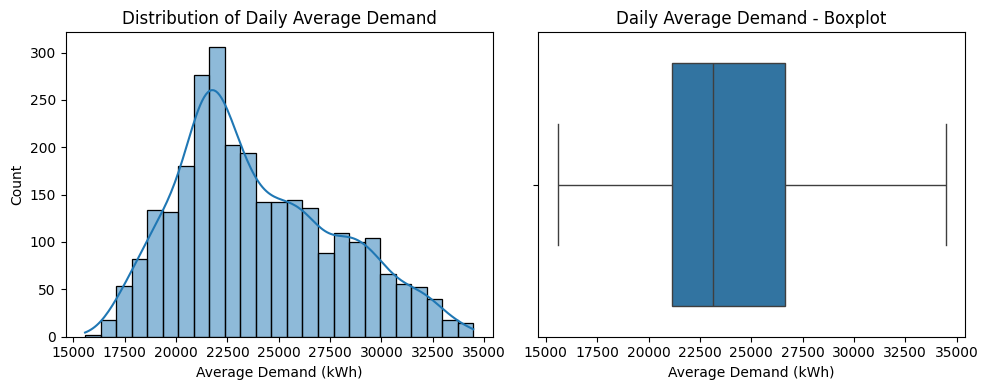

In [19]:
# Daily Average Demand
data = pd.to_numeric(df_weather_obs['daily_avg_demand'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Daily Average Demand")
plt.xlabel("Average Demand (kWh)")

plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Daily Average Demand - Boxplot")
plt.xlabel("Average Demand (kWh)")

plt.tight_layout()
plt.show()

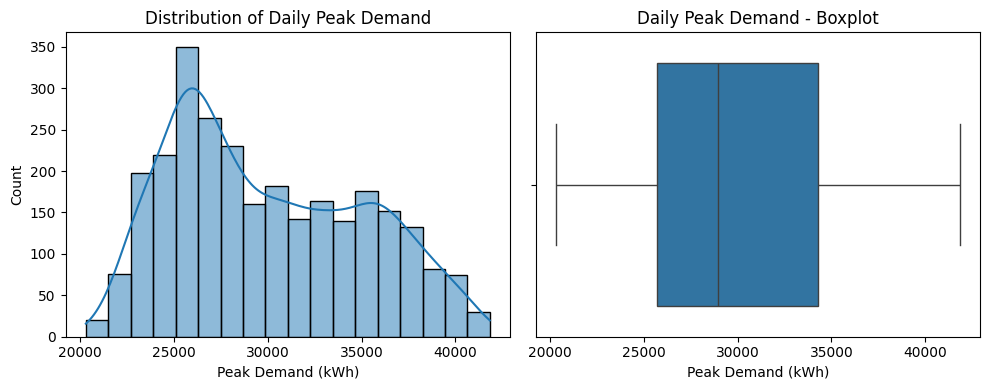

In [20]:
# Daily Peak Demand
data = pd.to_numeric(df_weather_obs['daily_peak_demand'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Daily Peak Demand")
plt.xlabel("Peak Demand (kWh)")


plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Daily Peak Demand - Boxplot")
plt.xlabel("Peak Demand (kWh)")


plt.tight_layout()
plt.show()

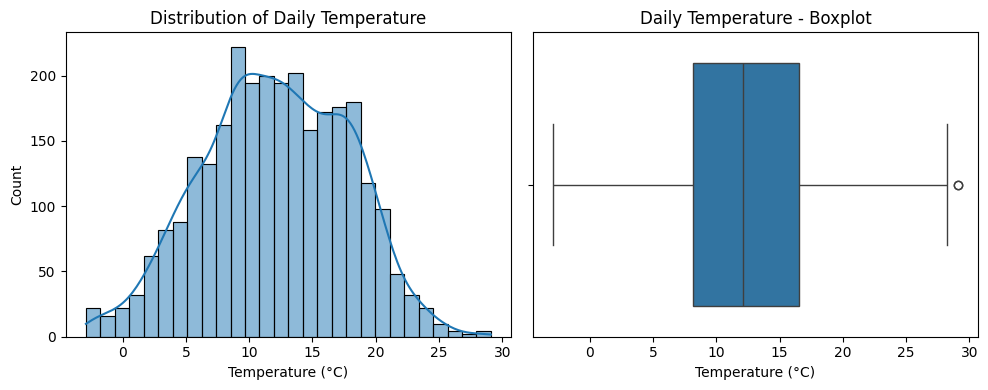

In [21]:

# Temperature 2m Mean
data = pd.to_numeric(df_weather_obs['temperature_2m_mean'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Daily Temperature")
plt.xlabel("Temperature (°C)")

plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Daily Temperature - Boxplot")
plt.xlabel("Temperature (°C)")

plt.tight_layout()
plt.show()

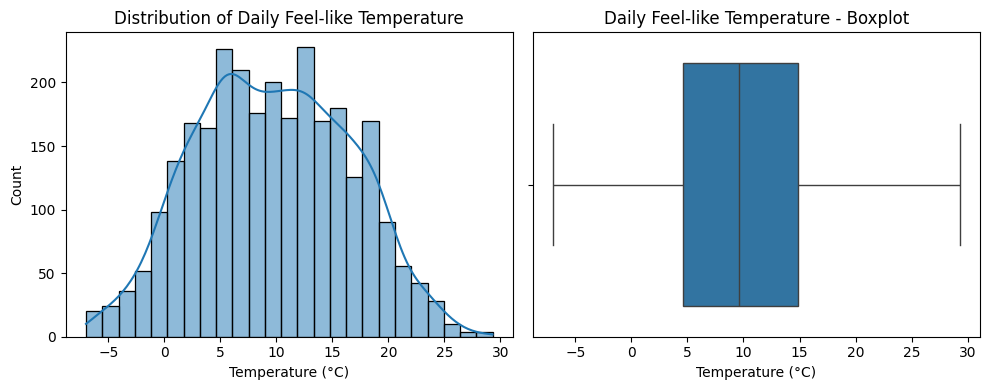

In [22]:
# Apparent Temperature Mean
data = pd.to_numeric(df_weather_obs['apparent_temperature_mean'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Daily Feel-like Temperature")
plt.xlabel("Temperature (°C)")


plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Daily Feel-like Temperature - Boxplot")
plt.xlabel("Temperature (°C)")


plt.tight_layout()
plt.show()

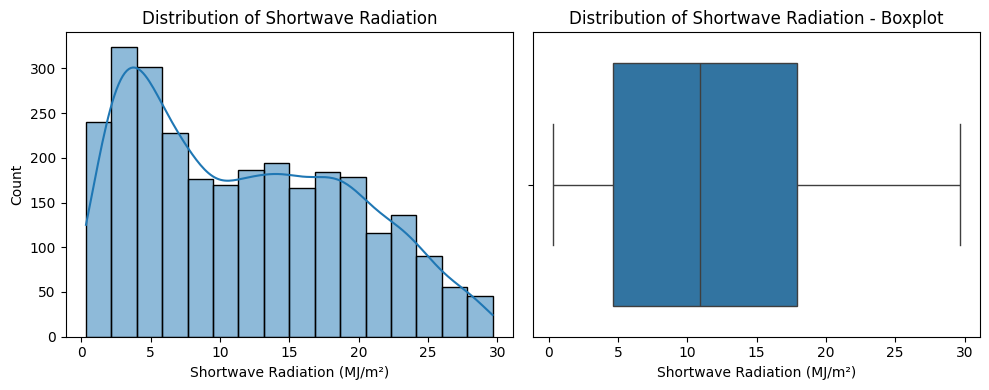

In [23]:
# Shortwave Radiation Sum
data = pd.to_numeric(df_weather_obs['shortwave_radiation_sum'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Shortwave Radiation")
plt.xlabel("Shortwave Radiation (MJ/m²)")


plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Distribution of Shortwave Radiation - Boxplot")
plt.xlabel("Shortwave Radiation (MJ/m²)")

plt.tight_layout()
plt.show()

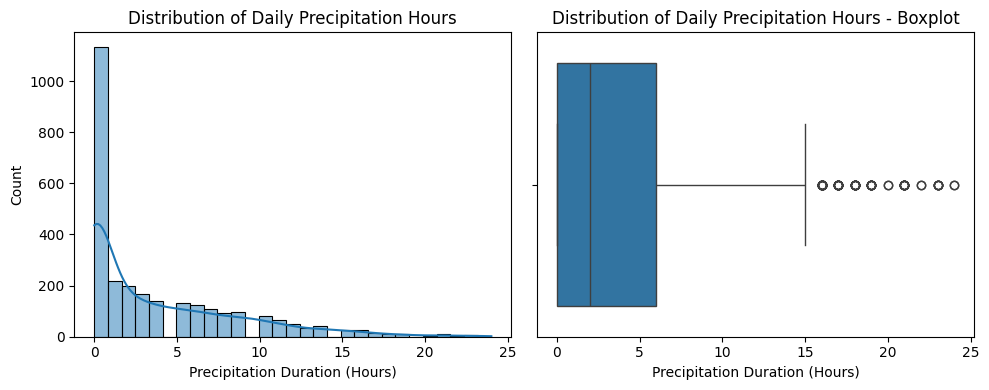

In [24]:
# Precipitation Hours
data = pd.to_numeric(df_weather_obs['precipitation_hours'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Daily Precipitation Hours")
plt.xlabel("Precipitation Duration (Hours)")

plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Distribution of Daily Precipitation Hours - Boxplot")
plt.xlabel("Precipitation Duration (Hours)")

plt.tight_layout()
plt.show()

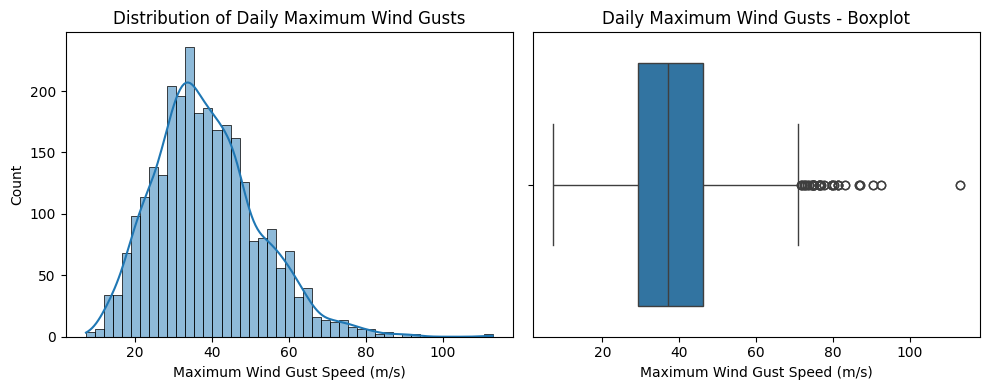

In [25]:
# Wind Gusts 10m Max
data = pd.to_numeric(df_weather_obs['wind_gusts_10m_max'], errors='coerce').dropna()
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Distribution of Daily Maximum Wind Gusts")
plt.xlabel("Maximum Wind Gust Speed (m/s)")

plt.subplot(1,2,2)
sns.boxplot(x=data)
plt.title("Daily Maximum Wind Gusts - Boxplot")
plt.xlabel("Maximum Wind Gust Speed (m/s)")

plt.tight_layout()
plt.show()

In [26]:
columns_to_plot = [
    "daily_avg_demand",
    "daily_peak_demand",
    "temperature_2m_mean",
    "apparent_temperature_mean",
    "shortwave_radiation_sum",
    "precipitation_hours",
    "wind_gusts_10m_max"
]

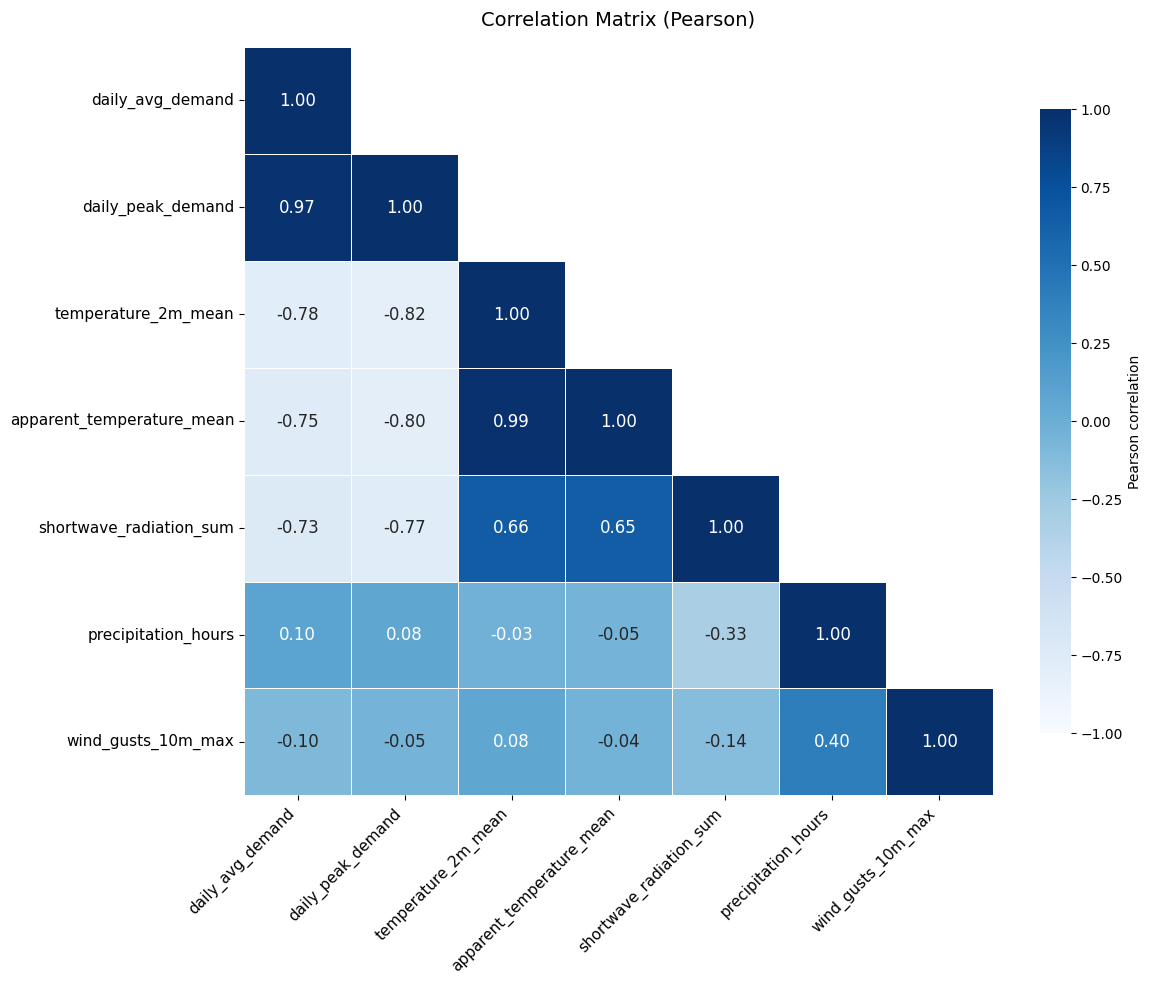

In [27]:
df_corr = df_weather_obs[columns_to_plot].dropna()
corr = df_corr.corr(method='pearson')

# Mask only the upper triangle (keep the diagonal visible)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Blues",      # clear diverging palette
    vmin=-1, vmax=1,      # full correlation range
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 12},
    cbar_kws={"shrink": 0.8, "label": "Pearson correlation"}
)

# Title and tick-label formatting
ax.set_title("Correlation Matrix (Pearson)", fontsize=14, pad=16)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=11
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=11
)

plt.tight_layout()
plt.show()

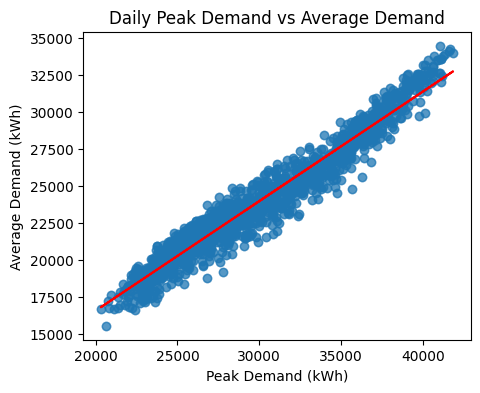

In [28]:
x = df_weather_obs["daily_peak_demand"]
y = df_weather_obs["daily_avg_demand"]

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Peak Demand (kWh)")
plt.ylabel("Average Demand (kWh)")
plt.title("Daily Peak Demand vs Average Demand")

plt.show()

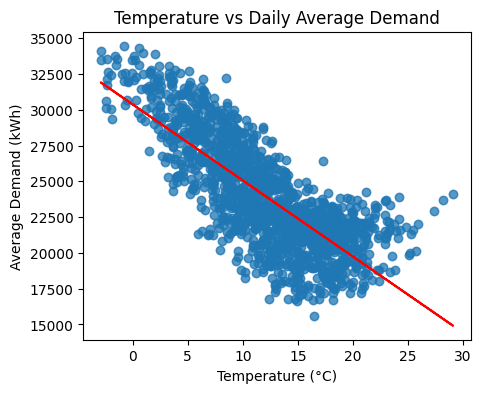

In [29]:
x = df_weather_obs["temperature_2m_mean"]
y = df_weather_obs["daily_avg_demand"]

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Temperature (°C)")
plt.ylabel("Average Demand (kWh)")
plt.title("Temperature vs Daily Average Demand")

plt.show()

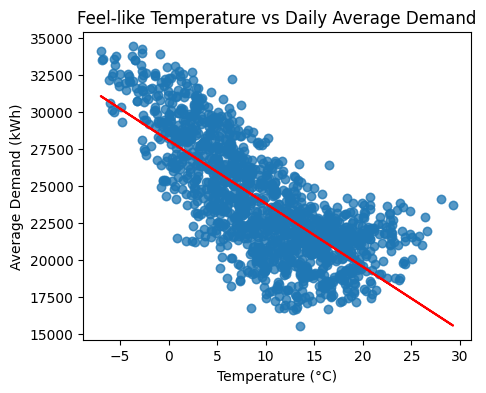

In [30]:
x = df_weather_obs["apparent_temperature_mean"]
y = df_weather_obs["daily_avg_demand"]

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Temperature (°C)")
plt.ylabel("Average Demand (kWh)")
plt.title("Feel-like Temperature vs Daily Average Demand")

plt.show()

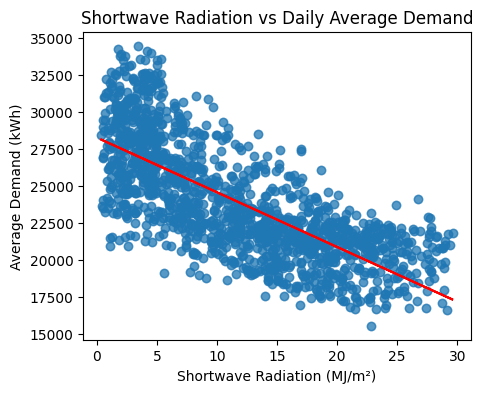

In [31]:
x = df_weather_obs["shortwave_radiation_sum"]
y = df_weather_obs["daily_avg_demand"]

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Shortwave Radiation (MJ/m²)")
plt.ylabel("Average Demand (kWh)")
plt.title("Shortwave Radiation vs Daily Average Demand")

plt.show()

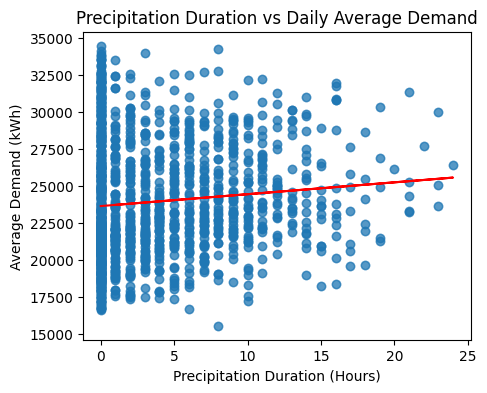

In [32]:
x = df_weather_obs["precipitation_hours"]
y = df_weather_obs["daily_avg_demand"]

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Precipitation Duration (Hours)")
plt.ylabel("Average Demand (kWh)")
plt.title("Precipitation Duration vs Daily Average Demand")

plt.show()

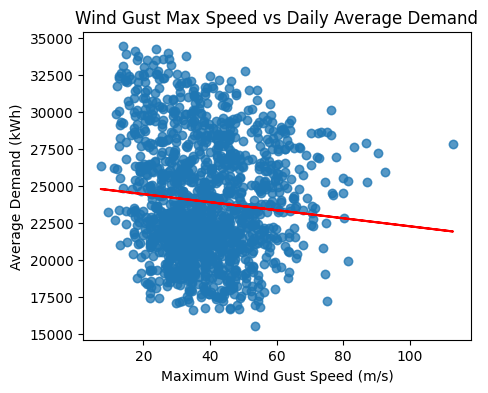

In [33]:
x = df_weather_obs["wind_gusts_10m_max"]
y = df_weather_obs["daily_avg_demand"]

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.5)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red")

plt.xlabel("Maximum Wind Gust Speed (m/s)")
plt.ylabel("Average Demand (kWh)")
plt.title("Wind Gust Max Speed vs Daily Average Demand")

plt.show()

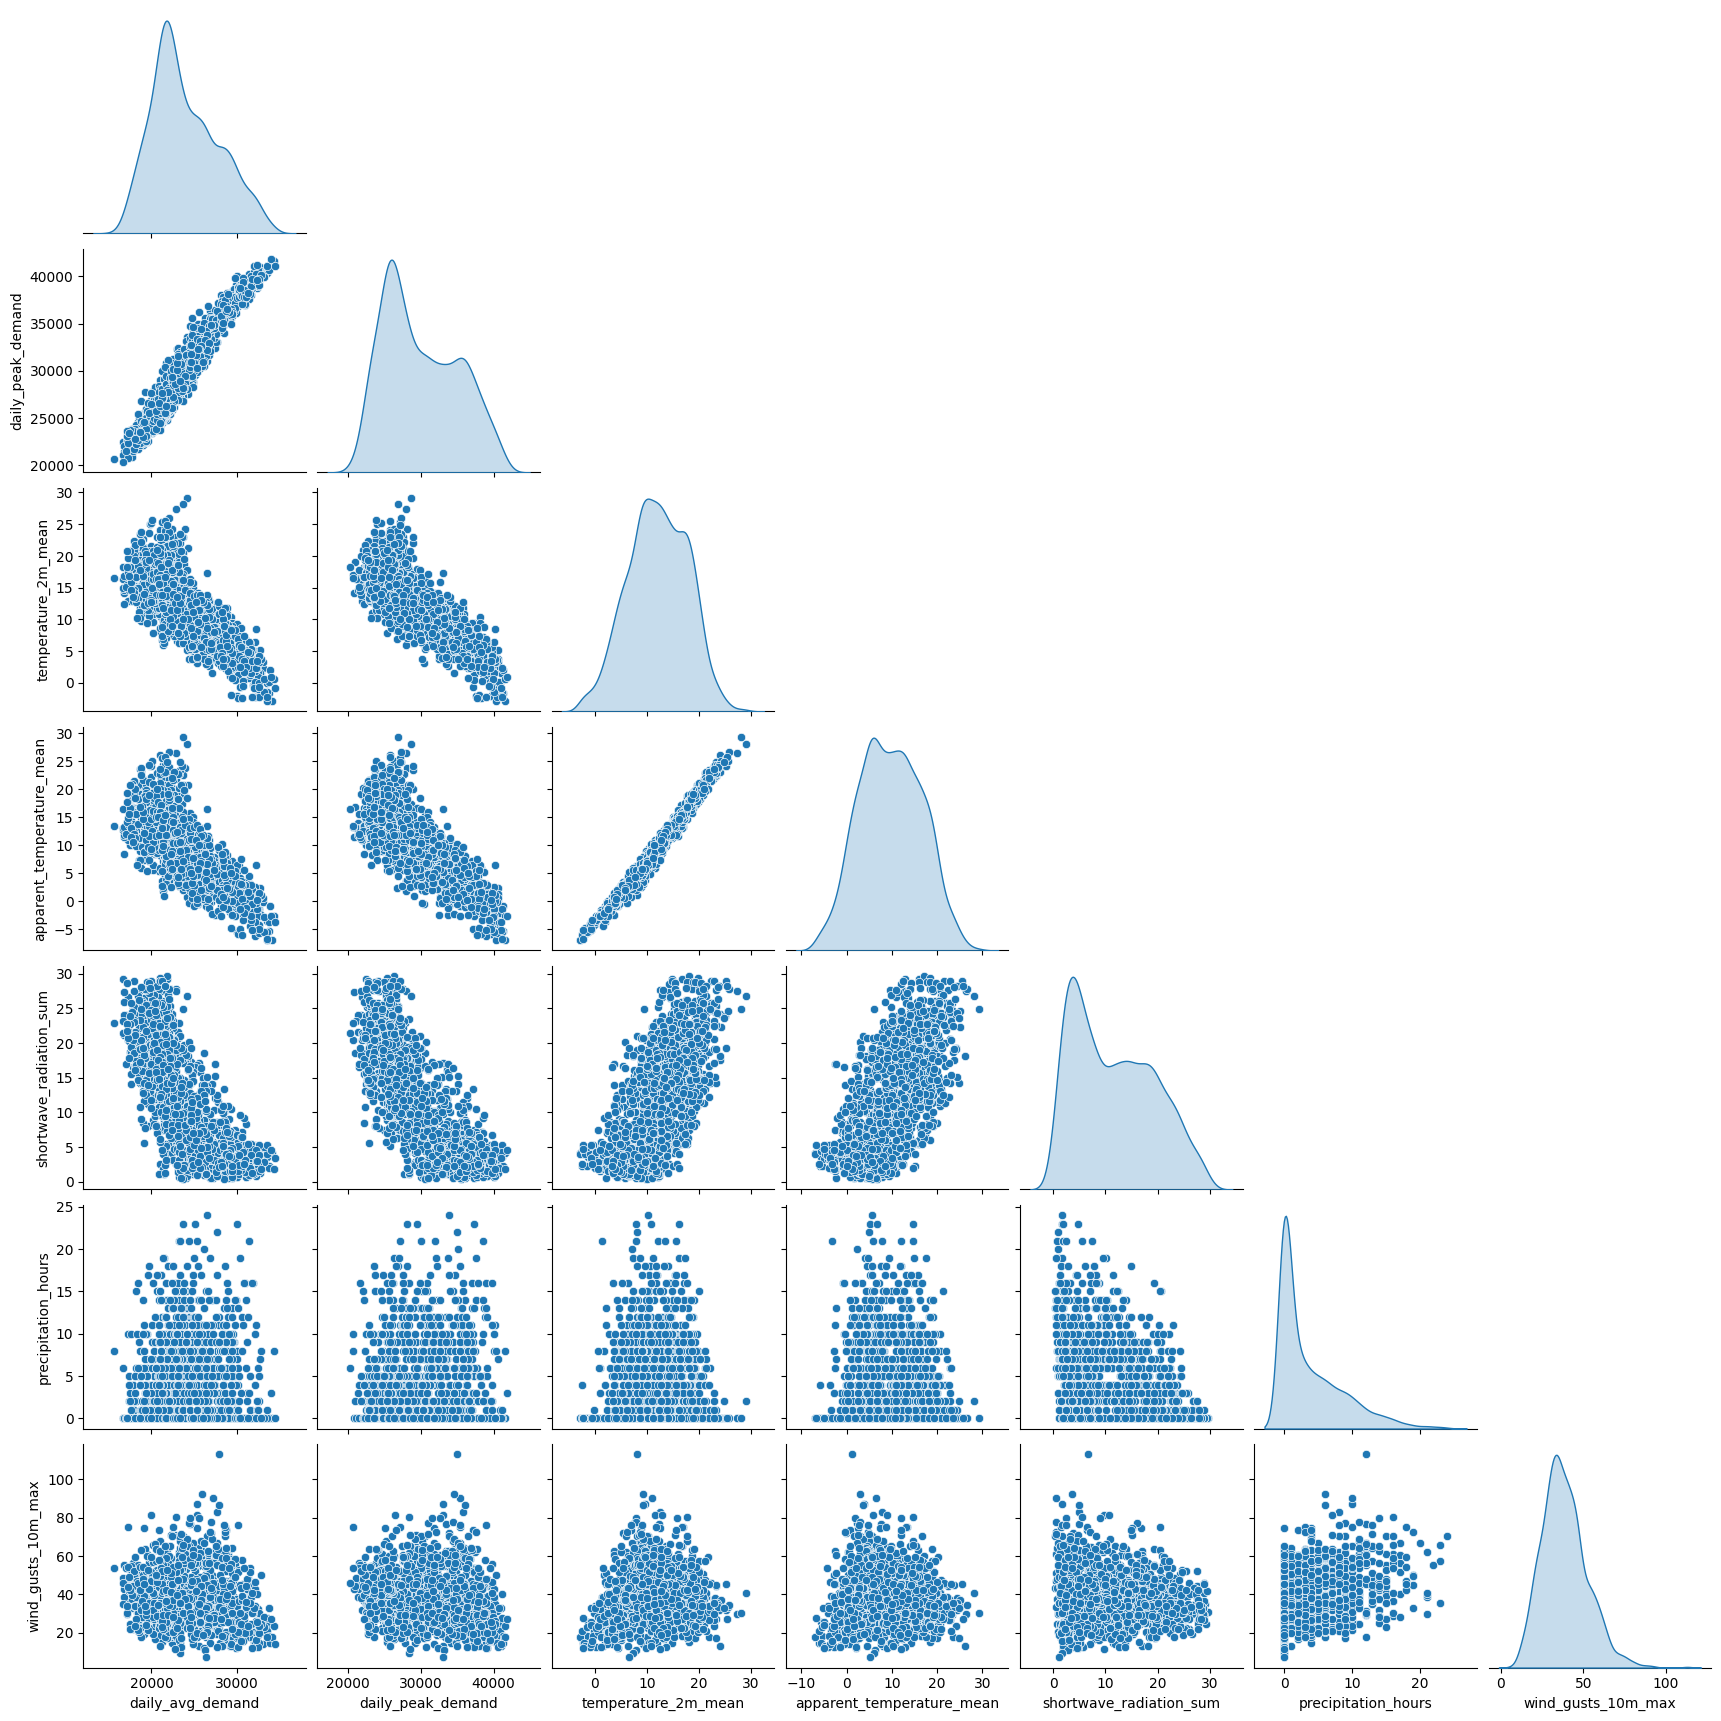

In [34]:
sns.pairplot(
    data=df_corr,
    corner=True,
    diag_kind='kde'
)

In [ ]:
#Plotting lineplot to check for seasonality
sns.lineplot(data=df_weather_obs,x='settlement_date',y='daily_avg_demand')
plt.xlabel("Settlement Date")
plt.ylabel("Average Demand (kWh)")
plt.title("Average Energy Demand by Day")

plt.show()

NameError: name 'sns' is not defined

## **Part 6. Modelling energy demand**

Finally, having explored the data, you can build a predictive model that will predict energy demand based on weather factors.

- You can use any regression model, from time series analysis models and linear regression to more complicated ML models, pick your poison! 

- You can use any of the techniques you have learned in your Data Science course at LBS. 

- The focus here is on how you source and use the data in a creative way rather than on finding the best model!

- Start simple, investigate the role of your variables and then make your model more complex. 

- It is important that you provide performance metrics of your model on data that it has not seen (train/test split). When you have time series data, you cannot mix past and future so you cannot use the traditional scikit learn train/test function. The simplest option is to say that the **train** dataset is from the beginning of your time series, say 2015, to, say, 2023. The test dataset can be the remaining time (2023 - 2025). Of course you can change these dates! 

- If you wish to be fancier and use a K-fold validation approach, you should not use the standard K-fold method. Have a look at this [article](https://towardsdatascience.com/how-to-cross-validation-with-time-series-data-9802a06272c6/) for further information.

- Building a model corresponds to creating a narrative! If you create a black-box model that performs incredibly well, but you find it difficult to interpret and communicate to stakeholders, then it might not be "the best" model! 

---
**If you need more Python libraries:**
- I have already added to the virtual environment data analysis and modelling libraries such as statsmodels (regression models) and scikit-learn (ML)
- If you need more libraries, **use uv**:
    - add the library that you need by opening the terminal in VSCode and typing *uv add name_of_the_library*
    - then, type *uv lock*
    - you should now have the library installed and you can import it in the notebook! 
---

**Example of forecasting model**

Below, you can find the simplest linear regression model trying to predict avg daily demand using just the temperature from the observation dataset. This model is trained on data before the end of 2023 and tested on the remaining data. It's just an example! Can you do better than this?

In [137]:
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import root_mean_squared_error , r2_score
from matplotlib import pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.stattools import durbin_watson

In [138]:
#Diagnostic plots 
def residualgraph(model,df):
    #Extracting residuals from model
    resid=model.resid
    predicts=model.predict(df)

    #Residual plot- check if residuals are random and not heteroskadastic 
    sns.scatterplot(x=resid,y=predicts)
    plt.title("Residuals Plot")
    plt.xlabel("Residuals")
    plt.ylabel("Predicted Variables")
    plt.show()
    
    #QQ plot- check if residuals follow a normal distribution
    sm.qqplot(resid,line='45',fit=True)
    plt.title("QQ-Plot")
    plt.show()

In [36]:
# Split by year
is_before = df_weather_obs["settlement_date"].dt.year <= 2023
train_df , test_df = df_weather_obs[is_before] , df_weather_obs[~is_before]

# Train on the training data
regression_model = smf.ols('daily_avg_demand ~ temperature_2m_mean',data=train_df).fit()

# Check r-squared and rmse in training dataset
r2_train = regression_model.rsquared
rmse_train = np.sqrt(regression_model.mse_resid)

# Test on the remaining data
predictions = regression_model.predict(test_df)

# Check r2 and rmse in test dataset
r2_test = r2_score(test_df["daily_avg_demand"],predictions)
rmse_test = root_mean_squared_error(test_df["daily_avg_demand"],predictions)

print(f"The r-squared of this model is {r2_train:.2f} (train) and {r2_test:.2f} (test)")
print(f"The RMSE of this model is {rmse_train:.0f} (train) and {rmse_test:.0f} (test)")

The r-squared of this model is 0.60 (train) and 0.61 (test)
The RMSE of this model is 2414 (train) and 2451 (test)


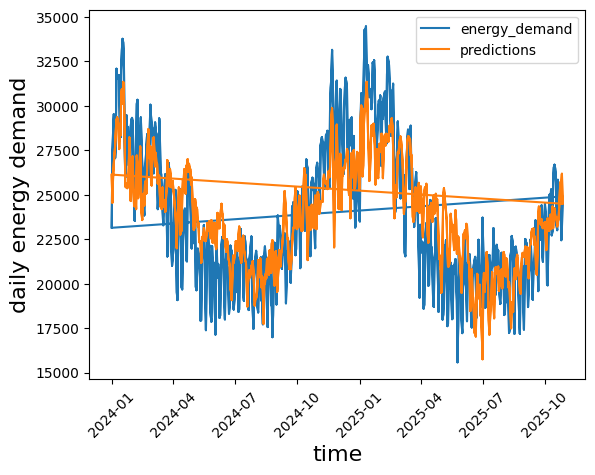

In [37]:
plt.plot(test_df["time"],test_df["daily_avg_demand"], label = "energy_demand")
plt.plot(test_df["time"],predictions,label="predictions")
plt.xlabel("time",size=16)
plt.ylabel("daily energy demand",size=16)
plt.xticks(rotation=45)
plt.legend()

In [113]:
import statsmodels.formula.api as smf
import numpy as np
from sklearn.metrics import root_mean_squared_error , r2_score
from matplotlib import pyplot as plt
import statsmodels.api as sm

# Split by year
df_weather_obs=df_weather_obs.copy()
is_before = df_weather_obs["settlement_date"].dt.year <= 2023
df_weather_obs['shift1']=df_weather_obs['daily_avg_demand'].shift(1)
df_weather_obs['shift7']=df_weather_obs['daily_avg_demand'].shift(7)
df_weather_obs['year']=df_weather_obs["settlement_date"].dt.year
train_df , test_df = df_weather_obs[is_before] , df_weather_obs[~is_before]

In [ ]:
# Train on the training data
regression_model3 = smf.ols('daily_avg_demand ~ year+shift1+shift7+temperature_2m_mean+shortwave_radiation_sum',data=train_df).fit()

# Check r-squared and rmse in training dataset
r2_train = regression_model3.rsquared
rmse_train = np.sqrt(regression_model3.mse_resid)

# Test on the remaining data
predictions = regression_model3.predict(test_df)

# Check r2 and rmse in test dataset
r2_test = r2_score(test_df["daily_avg_demand"],predictions)
rmse_test = root_mean_squared_error(test_df["daily_avg_demand"],predictions)

print(regression_model3.summary())
print(f"The r-squared of this model is {r2_train:.2f} (train) and {r2_test:.2f} (test)")
print(f"The RMSE of this model is {rmse_train:.0f} (train) and {rmse_test:.0f} (test)")

#Durbin Watson test statistic is 1.2, which indicates positive autocorrelation in the residuals
#Linear model is not appropriate to use

                            OLS Regression Results                            
Dep. Variable:       daily_avg_demand   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1823.
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        13:00:29   Log-Likelihood:                -12597.
No. Observations:                1453   AIC:                         2.521e+04
Df Residuals:                    1447   BIC:                         2.524e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3

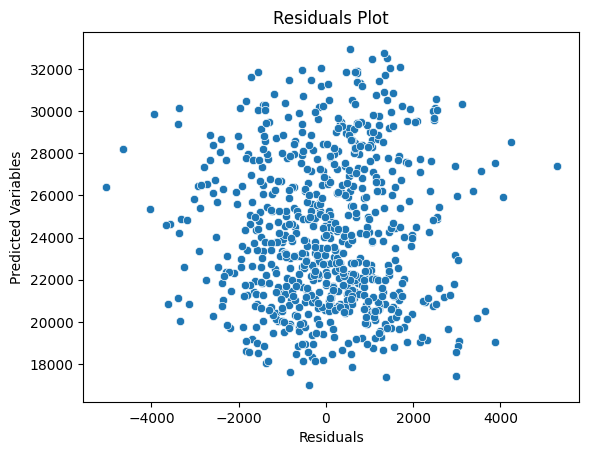

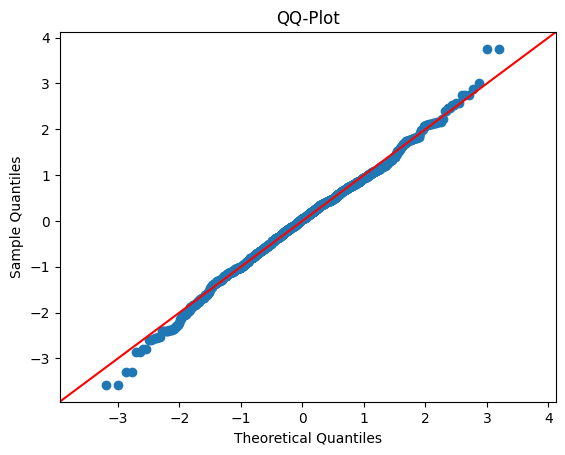

In [ ]:
#Checking model assumptions
residualgraph(regression_model3,train_df)

In [234]:
# Prepare data for modelling

# create a copy of the df
df = df_weather_obs.copy()

# Make sure dates are proper datetimes and sorted in time
df["settlement_date"] = pd.to_datetime(df["settlement_date"])
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("settlement_date")

# Calendar features: weekday, month, weekend, bank holiday
df["day_of_week"] = df["settlement_date"].dt.dayofweek      # 0 = Monday
df["month"]       = df["settlement_date"].dt.month
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
df["is_bank_holiday"] = df["is_bank_holiday"].fillna(0).astype(int)

# Simple demand lags to capture “memory”
df["lag1"] = df["daily_avg_demand"].shift(1)        # the day before
df["lag7"] = df["daily_avg_demand"].shift(7)        # last week info
df["temp_lag1"] = df["temperature_2m_mean"].shift(1) # Temperature from the day before
df["radiation_lag1"] = df["shortwave_radiation_sum"].shift(1)

# Features going into the model
feature_cols = [ "lag1","lag7",
    "temperature_2m_mean",
    "shortwave_radiation_sum",
    "precipitation_hours",
    "wind_gusts_10m_max",
    "is_weekend",
    "day_of_week",
    "month",
    "is_bank_holiday",
    "temp_lag1",
    "radiation_lag1"
]

# Drop rows where we’re missing target or any feature (mainly from lags)
df_model = df.dropna(subset=["daily_avg_demand"] + feature_cols)

/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/4137457647.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_bank_holiday"] = df["is_bank_holiday"].fillna(0).astype(int)


In [235]:
# Train / Test split (time-based)

# Train: up to end of 2023, Test: 2024 onwards
is_before = df_model["settlement_date"].dt.year <= 2023
train_df = df_model[is_before]
test_df  = df_model[~is_before]

y_train = train_df["daily_avg_demand"]
y_test  = test_df["daily_avg_demand"]

X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]

#print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

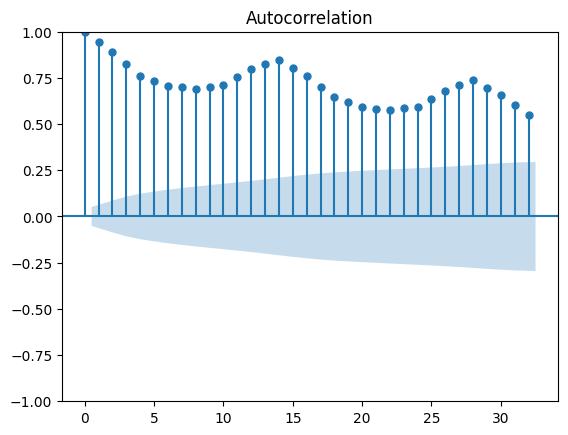

In [236]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Plotting ACF graph to determine seasonality
#Dominant spike at lag=1, set P=1 
#Data is non stationary, differencing may be required
#Choose seasonal order of 15: completes a seasonal cycle at order 15
plot_acf(y_train)
plt.show()

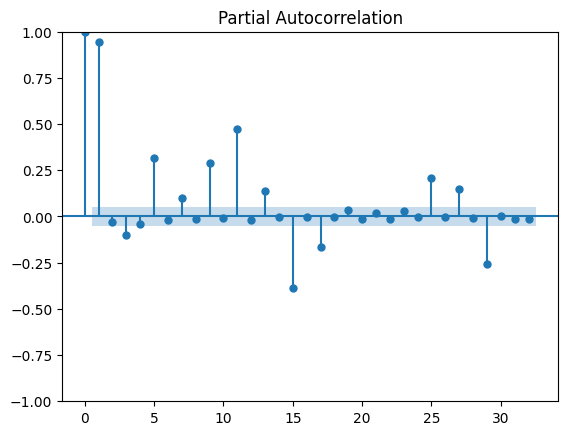

In [237]:
#Plotting PACF
plot_pacf(y_train)
plt.show()

#Data mostly falls within range after 2 but occassionally spikes at eg. lag= 5,11 
#and a significant negative spike at lag=15

In [238]:
# Fit SARIMAX (ARIMAX) model
# considers the weekdays stationary (not evaluate trends in increse/decrease when looking at past values)
# Considers data from the day before and also from the same weekday on the week before
# Differencing made model fit weaker

arimax_model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=(1, 0, 2),             # non-seasonal AR and MA
    seasonal_order=(1, 0, 2, 15), # biweekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(arimax_model.summary())

# Quick check on residual autocorrelation
dw_stat = sm.stats.durbin_watson(arimax_model.resid)
print(f"\nDurbin–Watson (in-sample residuals): {dw_stat:.3f}")

#Durbin Watson test statistic is 1.7, which is much closer to the ideal value of 2
#This indicates no significant problems with autocorrelation

/Users/christiechong/sql_group_assignment/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/christiechong/sql_group_assignment/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/christiechong/sql_group_assignment/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                   daily_avg_demand   No. Observations:                 1453
Model:             SARIMAX(1, 0, 2)x(1, 0, 2, 15)   Log Likelihood              -11677.614
Date:                            Sun, 23 Nov 2025   AIC                          23393.229
Time:                                    14:18:49   BIC                          23493.139
Sample:                                         0   HQIC                         23430.551
                                           - 1453                                         
Covariance Type:                              opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
lag1                        0.7988      0.015     52.690      0.000       0.769       0.

In [239]:
#Checking for autocorrelation with Ljung Box test
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(arimax_model.resid)

#No serial autocorrelation in lag=1 only

,lb_stat,lb_pvalue
1,1.846169,1.742296e-01
2,28.772034,5.652390e-07
3,29.131260,2.101618e-06
4,67.661652,7.070054e-14
5,77.928259,2.275433e-15
6,87.704175,9.078865e-17
7,88.919515,2.061868e-16
8,91.050511,2.845495e-16
9,91.933865,6.657672e-16
10,165.320040,2.578981e-30


In [240]:
# --- 1. Get fitted values (in-sample) ---
fitted = arimax_model.fittedvalues  # same index as y_train

# --- 2. Get exogenous coefficients (beta) ---
param_names = arimax_model.param_names
params = arimax_model.params

# exog names are exactly your feature cols
exog_names = X_train.columns

# Build a Series of exog coefficients in the right order
beta_exog = pd.Series(
    [params[param_names.index(name)] for name in exog_names],
    index=exog_names
)

# --- 3. Regression component: X * beta ---
regression_component = (X_train @ beta_exog).rename("regression_part")

# --- 4. ARIMA component: whatever is left over ---
arma_component = (fitted - regression_component).rename("arma_part")

# Put everything in one dataframe for convenience
# Combine actual, fitted and components into a dataframe WITH dates
decomp_df = pd.DataFrame({
    "actual": y_train,
    "fitted": fitted,
    "regression_part": regression_component,
    "arma_part": arma_component
})

# Make sure the index is the real datetime index
decomp_df.index = train_df["time"]
decomp_plot = decomp_df.tail(300)



/var/folders/d6/87l3cfjx4wzbt9yfj8z_pp9c0000gn/T/ipykernel_91410/1108927345.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [params[param_names.index(name)] for name in exog_names],


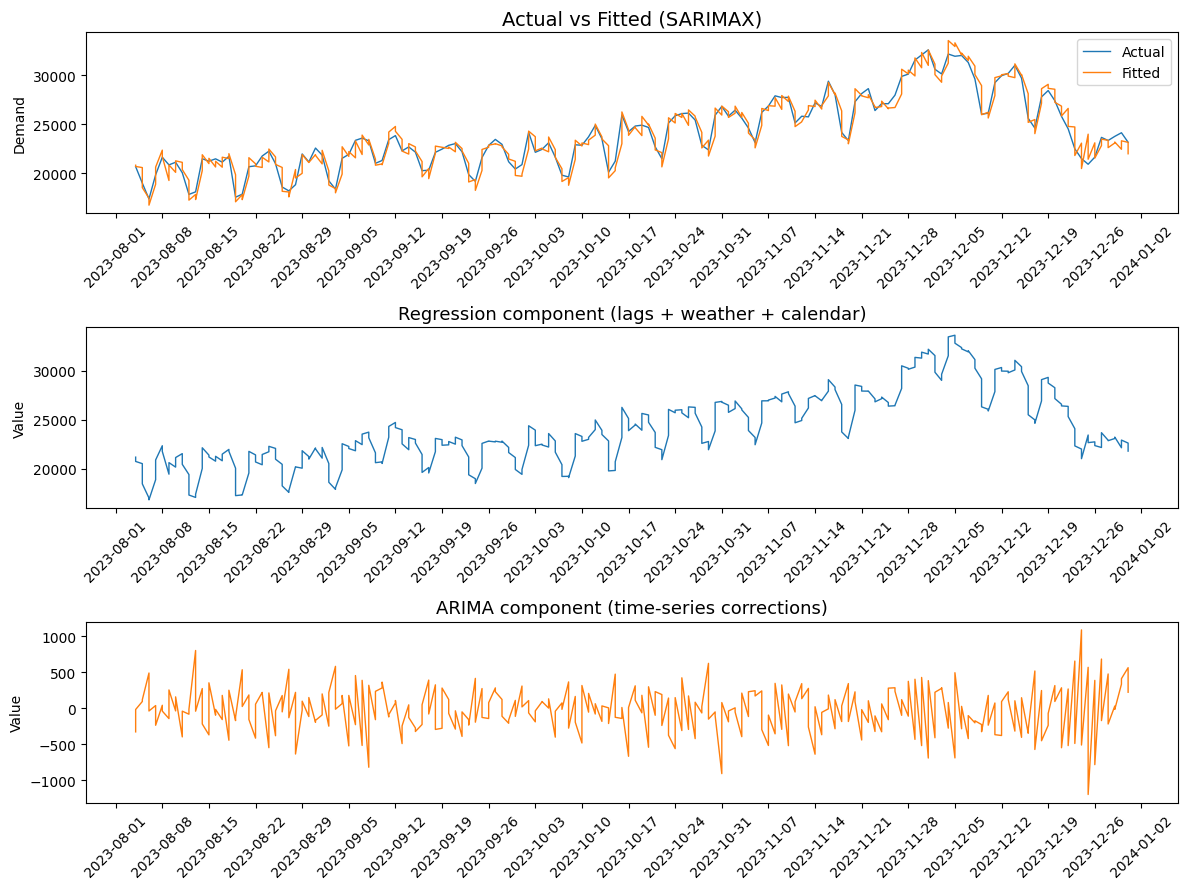

In [241]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 9))

# Choose a tick locator (more frequent)
locator = mdates.WeekdayLocator(interval=1)   # every week
formatter = mdates.DateFormatter("%Y-%m-%d")

# --- Plot 1: Actual vs Fitted ---
ax1 = plt.subplot(3, 1, 1)
ax1.plot(decomp_plot.index, decomp_plot["actual"], label="Actual", linewidth=1)
ax1.plot(decomp_plot.index, decomp_plot["fitted"], label="Fitted", linewidth=1)
ax1.set_title("Actual vs Fitted (SARIMAX)", fontsize=14)
ax1.set_ylabel("Demand")
ax1.legend()

ax1.xaxis.set_major_locator(locator)
ax1.xaxis.set_major_formatter(formatter)
plt.setp(ax1.get_xticklabels(), rotation=45)

# --- Plot 2: Regression component ---
ax2 = plt.subplot(3, 1, 2)
ax2.plot(decomp_plot.index, decomp_plot["regression_part"], color="tab:blue", linewidth=1)
ax2.set_title("Regression component (lags + weather + calendar)", fontsize=13)
ax2.set_ylabel("Value")

ax2.xaxis.set_major_locator(locator)
ax2.xaxis.set_major_formatter(formatter)
plt.setp(ax2.get_xticklabels(), rotation=45)

# --- Plot 3: ARIMA component ---
ax3 = plt.subplot(3, 1, 3)
ax3.plot(decomp_plot.index, decomp_plot["arma_part"], color="tab:orange", linewidth=1)
ax3.set_title("ARIMA component (time-series corrections)", fontsize=13)
ax3.set_ylabel("Value")

ax3.xaxis.set_major_locator(locator)
ax3.xaxis.set_major_formatter(formatter)
plt.setp(ax3.get_xticklabels(), rotation=45)


plt.tight_layout()
plt.show()


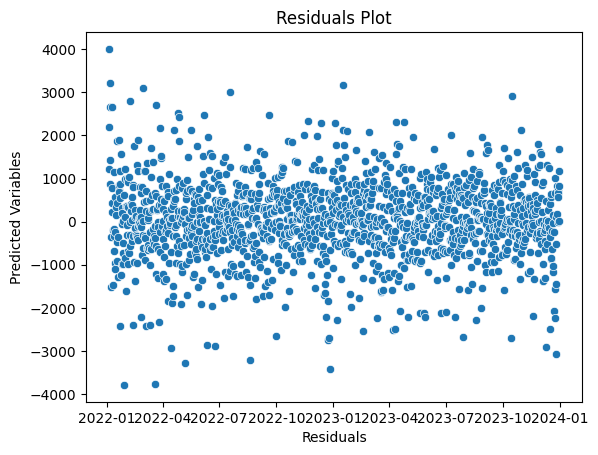

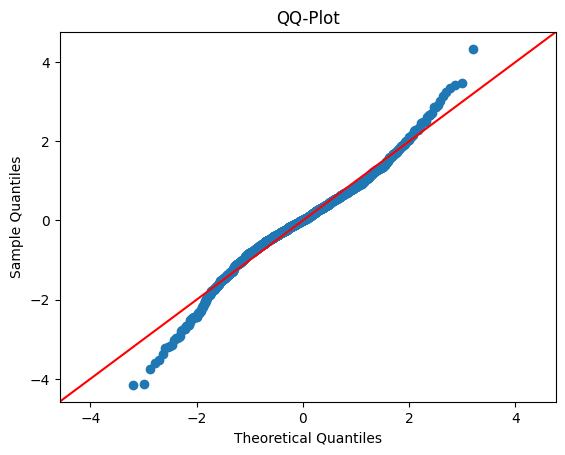

In [242]:
#Checking model assumptions
sarima_resid=arimax_model.resid

#Residual plot against time 
#No significnat pattern observed 
sns.scatterplot(x=train_df['settlement_date'],y=sarima_resid)
plt.title("Residuals Plot")
plt.xlabel("Residuals")
plt.ylabel("Predicted Variables")
plt.show()

#QQ plot- check if residuals follow a normal distribution
#Residuals mostly stick around the 45 degree line
sm.qqplot(sarima_resid,line='45',fit=True)
plt.title("QQ-Plot")
plt.show()

In [243]:
# Forecast on test period

n_test = len(y_test)

# Forecast next n_test days using test exogenous data
forecast_res = arimax_model.get_forecast(steps=n_test, exog=X_test)
pred_arimax = forecast_res.predicted_mean

# Line up predictions with actuals
pred_arimax.index = y_test.index

# Test metrics
r2_arimax = r2_score(y_test, pred_arimax)
rmse_arimax = root_mean_squared_error(y_test, pred_arimax)

print(f"\nARIMAX — Test R²:  {r2_arimax:.4f}")
print(f"ARIMAX — Test RMSE: {rmse_arimax:.2f}")


ARIMAX — Test R²:  0.9439
ARIMAX — Test RMSE: 930.58


/Users/christiechong/sql_group_assignment/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/christiechong/sql_group_assignment/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [244]:
# In-sample fitted values (train predictions)
fitted_train = arimax_model.fittedvalues  # same length as y_train

# Make sure indexes line up (just in case)
fitted_train = fitted_train.loc[y_train.index]

r2_train = r2_score(y_train, fitted_train)
rmse_train = root_mean_squared_error(y_train, fitted_train)

print(f"SARIMAX — Train R²:  {r2_train:.4f}")
print(f"SARIMAX — Train RMSE: {rmse_train:.2f}")

SARIMAX — Train R²:  0.9422
SARIMAX — Train RMSE: 919.11


In [245]:
#Getting R squared on SARIMA
sarima_pred=pred_arimax.values

r2_test = r2_score(test_df["daily_avg_demand"],sarima_pred)
rmse_test = root_mean_squared_error(test_df["daily_avg_demand"],sarima_pred)

print(f"The r-squared of this model is {r2_train:.2f} (train) and {r2_test:.2f} (test)")
print(f"The RMSE of this model is {rmse_train:.0f} (train) and {rmse_test:.0f} (test)")


The r-squared of this model is 0.94 (train) and 0.94 (test)
The RMSE of this model is 919 (train) and 931 (test)


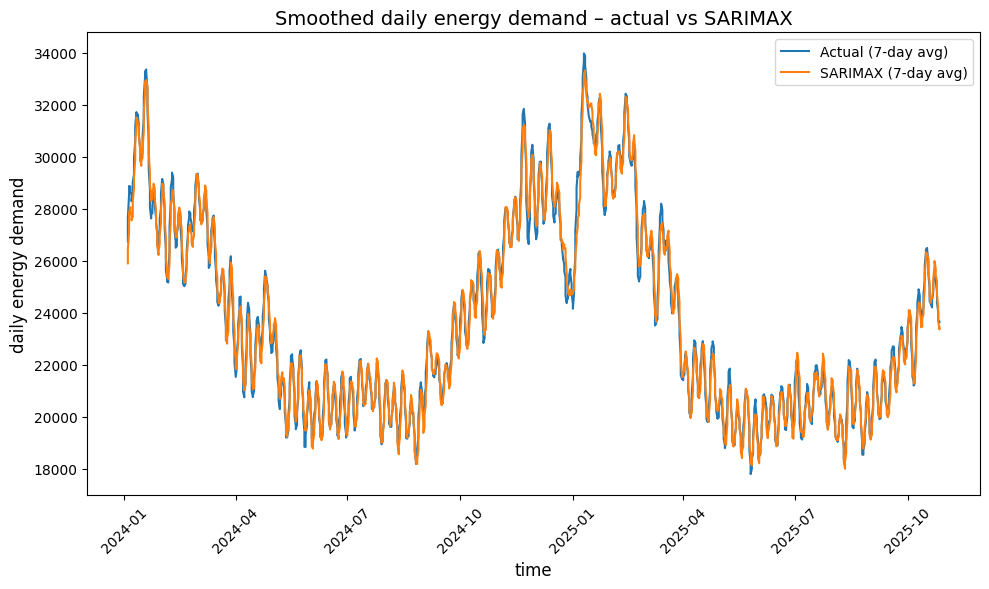

In [246]:
# Make a tidy dataframe for plotting
plot_df = test_df.copy().sort_values("time")

# Make sure pred_arimax lines up by row order
plot_df["sarimax_pred"] = pred_arimax.values

plot_df["actual_7d"] = plot_df["daily_avg_demand"].rolling(7).mean()
plot_df["pred_7d"]   = plot_df["sarimax_pred"].rolling(7).mean()

plt.figure(figsize=(10, 6))
plt.plot(plot_df["time"], plot_df["actual_7d"], label="Actual (7-day avg)")
plt.plot(plot_df["time"], plot_df["pred_7d"],   label="SARIMAX (7-day avg)")
plt.xlabel("time", fontsize=12)
plt.ylabel("daily energy demand", fontsize=12)
plt.title("Smoothed daily energy demand – actual vs SARIMAX", fontsize=14)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## **Part 7. Refine and Write up!** 

Once you have a baseline model, you can think of ways to improve it. 

Below, I will leave you a few questions and ideas that you might want to pursue. 

**You don't need to implement all of them, you can pick some that inspire you the most, or you might go for something completely different. This is your chance to be creative!** 

- Change the model, and compare different approaches. Is there one that works best?

- Change the data on which the model is trained and/or tested. Include new energy/weather data. Find other potential sources of data! If you want to delete a table, you can just right-click and select Delete. You can then re-create a new one with different information!

- Seasonality and trends. Maybe you want to include in your model some trend? At the moment we are not using any information from the calendar table. Do bank holidays affect the energy demand? 

- How about using textual data? Can you use embeddings? What kind of data could be appropriate for this forecasting task? What could you do with it? You do not necessarily need to include textual data in your forecasting model, but you could provide recommendations and possible ways to leverage this information for the prediction of future energy demand.

- Given your current data and approach, would you be able to predict the energy demand for the week right after the deadline of the assignment? 

--- 
**Deliverables for the assignment**

Once you are happy with your full pipeline (data acquisition -> processing -> storing -> analysis), write up!

- Prepare some slides for a presentation: this is an executive briefing targeted to senior decision-makers. You should include business insights regarding the full modelling pipeline by providing data-driven evidence, but avoid using excessive technicalities at this stage! A plot goes a long way when communicating complicated information. 

- Prepare a report, this can feature more technical parts for future reference at PowerCo. This can also feature a what worked/didn't work section if you think it's appropriate and if it provides insight on the data modelling process.

For more information, check the assignment brief! 